# Feed Forward Neural Network

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import gzip
import numpy as np
import matplotlib.pyplot as plt

First, we will import the **MNIST** dataset. We will be creating a Feed Forward Neural Network for it.

In [8]:
def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [9]:
# first, load train-val
xtrain_val = get_images('data/train-images-idx3-ubyte.gz')
ytrain_val = get_labels('data/train-labels-idx1-ubyte.gz')

# then, load test
xtest = get_images('data/t10k-images-idx3-ubyte.gz')
ytest = get_labels('data/t10k-labels-idx1-ubyte.gz')

# split into 50k, 10k, 10k
xtrain = xtrain_val[:50000]
ytrain = ytrain_val[:50000]
xval = xtrain_val[50000:]
yval = ytrain_val[50000:]
# test is already 10k

We also need to flatten the 28x28 image.

In [ ]:
xtrain = xtrain.reshape((xtrain.shape[0], -1)).astype(np.float32)
xval = xval.reshape((xval.shape[0], -1)).astype(np.float32)
xtest = xtest.reshape((xtest.shape[0], -1)).astype(np.float32)
ytrain = ytrain.reshape((ytrain.shape[0],))
yval = yval.reshape((yval.shape[0],))
ytest = ytest.reshape((ytest.shape[0],))

To ensure the validity of our dataset, let's try printing one of the entries

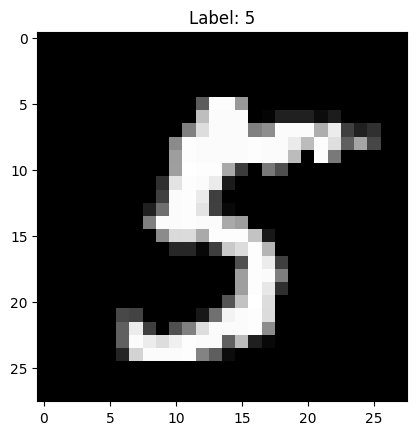

In [13]:
idx = np.random.randint(0, xtrain.shape[0])
plt.imshow(xtrain[idx].reshape((28, 28)), cmap='gray')
plt.title(f'Label: {ytrain[idx]}')
plt.show()

## Making the Network

We can kick it off by defining our network class, using PyTorch's `torch.nn` module and its `Sequential` model.

Our Feed Forward Network will have a forward pass implemented using a hidden layer, an activation function, an input layer (implicit), and an output layer.

We will use `Linear` layers and `ReLU` as our activation function.

In [ ]:
model = nn.Sequential(
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

There are 3 layers in this model:
- Input (implicit) of 784 neurons
- Hidden layer of 128 neurons
- Output layer of 10 neeurons (10 classes)

### Optimizer

Now, to improve the model by reducing overfitting, we can add an optimizer. The optimizer will help update the weights with a fixed decay rate that will punish weights that the model is relying too much on.

In [17]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### Loss Function

To measure the model's performance we need a metric that will determine the loss of the model's performance through its lifetime.

In [18]:
loss_fn = nn.CrossEntropyLoss()

Because this is a multiclass problem (we have 10 different classes in the pool), we can use `CrossEntropyLoss`. It uses a sigmoid function internally and will yield a probability for each class in the output.

## Training

We will manually train our model.

Our train function will do this each epoch (training iteration):
1. Train the model (forward pass on mini-batches)
2. Reset the gradients (per mini-batch)
3. Compute the loss (per mini-batch)
4. Compute the gradients (backward pass)
5. Update the weights using the optimizer (per mini-batch)
6. Evaluate the model with the validation set using the same loss function
7. Compute validation accuracy

In [21]:
def evaluate(model, loss_fn, xval, yval):
    model.eval()
    with torch.no_grad():
        val_outputs = model(torch.from_numpy(xval))
        val_loss = loss_fn(val_outputs, torch.from_numpy(yval))

        # accuracy
        preds = val_outputs.argmax(dim=1) # top probability
        acc = (preds == torch.from_numpy(yval)).float().mean()
    return val_loss.item(), acc.item()

def train(model, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs=10, batch_size=32):
    # for each epoch
    for epoch in range(epochs):
        # we train the model
        model.train()

        # loop over mini batches
        for i in range(0, len(xtrain), batch_size):
            batch_x = torch.from_numpy(xtrain[i:i+batch_size])
            batch_y = torch.from_numpy(ytrain[i:i+batch_size])

            # reset the GRADIENTS to zero
            optimizer.zero_grad()

            # compute outputs to measure the loss (forward pass)
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)

            # compute the GRADIENTS (backward pass)
            loss.backward()

            # update the WEIGHTS, as they were modified by the backward pass
            # this is what persists across iterations and epochs
            optimizer.step()

        # then we evaluate the model on the validation set
        # using torch.no_grad() to avoid computing gradients
        # and the loss_fn
        val_loss, acc = evaluate(model, loss_fn, xval, yval)

        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Val Acc: {acc.item():.4f}')

## First Network

In [24]:
# train with a set of parameters
train(model, optimizer, loss_fn, xtrain, ytrain, xval, yval, epochs=10, batch_size=32)

RuntimeError: mat1 and mat2 must have the same dtype, but got Byte and Float